In [1]:
%pip install pandas numpy matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.


# Knowledge Engineering: Grammy-WASABI Data Integration

## Phase 1 — Data Loading, Inspection & Normalization

Load each dataset, inspect its columns and first rows, filter the Grammy data to work-type records only, then apply a shared normalization function to prepare for matching.

In [8]:
import pandas as pd
import numpy as np
import re
import os

DATA_DIR = os.path.dirname(os.path.abspath("songs.ipynb"))

# ── Grammy: standard comma-separated CSV ──────────────────────────────────────
grammys_raw = pd.read_csv(os.path.join(DATA_DIR, "grammys.csv"), index_col=0)
print(f"Grammy rows   : {len(grammys_raw):,}")

# ── WASABI songs: tab-delimited, skip malformed rows ─────────────────────────
wasabi_songs = pd.read_csv(
    os.path.join(DATA_DIR, "wasabi_songs.csv"),
    sep="\t", low_memory=False, on_bad_lines="skip"
)
print(f"WASABI songs  : {len(wasabi_songs):,}")

# ── WASABI artists: comma-delimited, deeply nested JSON fields ────────────────
wasabi_artists = pd.read_csv(
    os.path.join(DATA_DIR, "wasabi_artists.csv"),
    on_bad_lines="skip", engine="python"
)
print(f"WASABI artists: {len(wasabi_artists):,}")

Grammy rows   : 25,305
WASABI songs  : 2,099,554
WASABI artists: 77,694


### 1.1 Inspect Grammy Dataset

In [9]:
print("=== Grammy columns ===")
print(list(grammys_raw.columns))
print("\n=== Grammy sample (5 rows) ===")
display(grammys_raw.head())
print("\n=== Grammy Award Types ===")
print(grammys_raw["Award Type"].value_counts())

=== Grammy columns ===
['Year', 'Ceremony', 'Award ID', 'Award Type', 'Award Name', 'Work', 'Nominee', 'Winner']

=== Grammy sample (5 rows) ===


,Year,Ceremony,Award ID,Award Type,Award Name,Work,Nominee,Winner
0,1958,1,587,Work,Best Recording For Children,Childrens' Marching Song (Album),Cyril Stapleton,False
1,1958,1,587,Work,Best Recording For Children,"Mommy, Give Me A Drinka Water (Album)",Danny Kaye,False
2,1958,1,587,Work,Best Recording For Children,The Witch Doctor,David Seville And The Chipmunks,False
3,1958,1,587,Work,Best Recording For Children,Tubby The Tuba,Jose Ferrer,False
4,1958,1,587,Work,Best Recording For Children,Fun In Shariland (Album),Shari Lewis And Lambchop,False



=== Grammy Award Types ===
Award Type
Work       24412
Nominee      893
Name: count, dtype: int64


### 1.2 Inspect WASABI Songs Dataset

In [10]:
print("=== WASABI Songs columns ===")
print(list(wasabi_songs.columns))

# Key production/metadata fields — check coverage
key_cols = ["title", "artist", "albumTitle", "genre", "bpm", "gain",
            "publicationDate", "language"]
available = [c for c in key_cols if c in wasabi_songs.columns]
missing   = [c for c in key_cols if c not in wasabi_songs.columns]
print(f"\nKey columns present : {available}")
print(f"Key columns absent  : {missing}")

print(f"\nNon-null counts for available key columns:")
print(wasabi_songs[available].notna().sum())

print("\n=== WASABI Songs sample (3 rows, key columns) ===")
display(wasabi_songs[available].head(3))

=== WASABI Songs columns ===
['Unnamed: 0', '_id', 'abstract', 'albumTitle', 'album_genre', 'animux_content', 'animux_contents', 'animux_path', 'animux_paths', 'arousal', 'arousal_predicted', 'artist', 'artist_lower', 'availableCountries', 'award', 'begin', 'bpm', 'chords_metadata', 'deezer_mapping', 'disambiguation', 'end', 'explicit_content_lyrics', 'explicit_content_lyrics_predicted', 'format', 'gain', 'genre', 'has_emotion_tags', 'has_social_tags', 'id_album', 'id_album_deezer', 'id_artist_deezer', 'id_song_deezer', 'id_song_musicbrainz', 'isClassic', 'isrc', 'langdetect_robust', 'language', 'language_detect', 'lastfm_id', 'length', 'lengthAlbum', 'multitrack_file', 'multitrack_path', 'newPreview', 'notes', 'origin', 'position', 'preview', 'producer', 'publicationDate', 'publicationDateAlbum', 'rank', 'rdf', 'recordLabel', 'recorded', 'releaseDate', 'runtime', 'subject', 'title', 'title_accent_fold', 'title_lower', 'urlAllmusic', 'urlAmazon', 'urlDeezer', 'urlGoEar', 'urlHypeMachin

,title,artist,albumTitle,genre,bpm,gain,publicationDate,language
0,Turn It Up,A,How Ace Are Buildings,NaN,77.0,-29.4,1998-06-22,NaN
1,Foghorn,A,How Ace Are Buildings,NaN,106.0,-10.6,1998-06-22,NaN
2,Cheeky Monkey,A,How Ace Are Buildings,NaN,185.0,-10.4,1998-06-22,NaN


In [11]:
# album_genre has better coverage — check it too
print("album_genre non-null:", wasabi_songs["album_genre"].notna().sum())
print("\nSample album_genre values:")
print(wasabi_songs["album_genre"].dropna().head(10).tolist())

album_genre non-null: 1059881

Sample album_genre values:
['Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock', 'Alternative Rock']


### 1.3 Inspect WASABI Artists Dataset

In [12]:
print("=== WASABI Artists columns ===")
print(list(wasabi_artists.columns))

name_col = "name" if "name" in wasabi_artists.columns else wasabi_artists.columns[0]
genre_col = "genres" if "genres" in wasabi_artists.columns else None

print(f"\nArtist name column : '{name_col}'")
print(f"Artist genre column: '{genre_col}'")
print(f"\nSample artist names:")
print(wasabi_artists[name_col].dropna().head(10).tolist())

if genre_col:
    print(f"\nSample genre values:")
    print(wasabi_artists[genre_col].dropna().head(10).tolist())

=== WASABI Artists columns ===
['_id', 'disambiguation', 'endArea', 'endArea.disambiguation', 'endArea.id', 'endArea.name', 'gender', 'genres', 'id_artist_musicbrainz', 'labels', 'lifeSpan', 'lifeSpan.begin', 'lifeSpan.end', 'lifeSpan.ended', 'location', 'location.city', 'location.country', 'location.id_city_musicbrainz', 'locationInfo', 'members', 'name', 'nameVariations_fold', 'name_accent_fold', 'rdf', 'type', 'urlAllmusic', 'urlAmazon', 'urlDiscogs', 'urlFacebook', 'urlITunes', 'urlMusicBrainz', 'urlMySpace', 'urlOfficialWebsite', 'urlPureVolume', 'urlRateYourMusic', 'urlSoundCloud', 'urlSpotify', 'urlTwitter', 'urlWikia', 'urlWikipedia', 'urlYouTube', 'id_artist_discogs', 'abstract', 'nameVariations', 'urls', 'deezerFans', 'id_artist_deezer', 'picture', 'picture.big', 'picture.medium', 'picture.small', 'picture.standard', 'picture.xl', 'urlDeezer', 'urlWikidata', 'associatedMusicalArtist', 'dbp_abstract', 'dbp_genre', 'recordLabel', 'subject', 'members.XX.begin', 'members.XX.disam

### 1.4 Filter Grammy to Work-type Records

Grammy contains two `Award Type` values:
- **Work** (24,412 rows) — nominations for a song/album. These are matchable against WASABI.
- **Nominee** (893 rows) — person/producer-level awards (e.g., "Producer of the Year"). No title to match against.

We keep only `Work` rows and rename columns to be more explicit.

In [13]:
# Keep only Work-type nominations (song/album level)
grammys = (
    grammys_raw[grammys_raw["Award Type"] == "Work"]
    .copy()
    .rename(columns={
        "Award Name": "category",
        "Work":       "work_title",
        "Nominee":    "artist",
        "Year":       "year",
        "Winner":     "winner",
    })
    .reset_index(drop=True)
)

# Drop rows where work_title or artist is missing (can't match these)
before = len(grammys)
grammys = grammys.dropna(subset=["work_title", "artist"])
print(f"Work-type rows        : {before:,}")
print(f"After dropping nulls  : {len(grammys):,}")
print(f"\nYear range            : {grammys['year'].min()} – {grammys['year'].max()}")
print(f"Unique categories     : {grammys['category'].nunique():,}")
print(f"Unique artists        : {grammys['artist'].nunique():,}")
print(f"Winners               : {grammys['winner'].sum():,}")
display(grammys.head(3))

Work-type rows        : 24,412
After dropping nulls  : 24,412

Year range            : 1958 – 2024
Unique categories     : 764
Unique artists        : 13,837
Winners               : 4,698


,year,Ceremony,Award ID,Award Type,category,work_title,artist,winner
0,1958,1,587,Work,Best Recording For Children,Childrens' Marching Song (Album),Cyril Stapleton,False
1,1958,1,587,Work,Best Recording For Children,"Mommy, Give Me A Drinka Water (Album)",Danny Kaye,False
2,1958,1,587,Work,Best Recording For Children,The Witch Doctor,David Seville And The Chipmunks,False


### 1.5 Normalization Function

A shared text normalization applied to both Grammy and WASABI fields before matching:
1. Lowercase
2. Strip parenthetical suffixes like `(Album)`, `(feat. X)`, `(Deluxe Edition)`, `(Remastered)`
3. Remove all punctuation
4. Collapse whitespace

In [14]:
_PAREN_RE = re.compile(r"\s*[\(\[].+?[\)\]]")   # strip (...) and [...]
_PUNCT_RE  = re.compile(r"[^\w\s]")              # remove non-word non-space
_SPACE_RE  = re.compile(r"\s+")                  # collapse whitespace

def normalize(text: str) -> str:
    """Lowercase → strip parentheticals → remove punctuation → collapse spaces."""
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = _PAREN_RE.sub("", t)
    t = _PUNCT_RE.sub("", t)
    t = _SPACE_RE.sub(" ", t).strip()
    return t

# ── Verify the function ────────────────────────────────────────────────────────
test_cases = [
    "Fearless (Taylor's Version)",
    "Blinding Lights (feat. The Weeknd)",
    "Abbey Road (Album)",
    "What's Going On",
    "  The  Beatles  ",
]
for tc in test_cases:
    print(f"  {tc!r:45s} → {normalize(tc)!r}")

  "Fearless (Taylor's Version)"                 → 'fearless'
  'Blinding Lights (feat. The Weeknd)'          → 'blinding lights'
  'Abbey Road (Album)'                          → 'abbey road'
  "What's Going On"                             → 'whats going on'
  '  The  Beatles  '                            → 'the beatles'


### 1.6 Apply Normalization to Grammy & WASABI

Add `_norm` columns to each dataset. These are the keys used for matching in Phase 2.

In [15]:
# ── Grammy: normalize artist and work title ───────────────────────────────────
grammys["artist_norm"]     = grammys["artist"].map(normalize)
grammys["work_title_norm"] = grammys["work_title"].map(normalize)

# ── WASABI songs: normalize title, albumTitle, and artist ─────────────────────
wasabi_songs["title_norm"]  = wasabi_songs["title"].map(normalize)
wasabi_songs["album_norm"]  = wasabi_songs["albumTitle"].map(normalize)
wasabi_songs["artist_norm"] = wasabi_songs["artist"].map(normalize)

print("Grammy — sample normalized rows:")
display(grammys[["work_title", "work_title_norm", "artist", "artist_norm"]].head(5))

print("\nWASABI — sample normalized rows:")
display(wasabi_songs[["title", "title_norm", "albumTitle", "album_norm", "artist", "artist_norm"]].head(5))

Grammy — sample normalized rows:


,work_title,work_title_norm,artist,artist_norm
0,Childrens' Marching Song (Album),childrens marching song,Cyril Stapleton,cyril stapleton
1,"Mommy, Give Me A Drinka Water (Album)",mommy give me a drinka water,Danny Kaye,danny kaye
2,The Witch Doctor,the witch doctor,David Seville And The Chipmunks,david seville and the chipmunks
3,Tubby The Tuba,tubby the tuba,Jose Ferrer,jose ferrer
4,Fun In Shariland (Album),fun in shariland,Shari Lewis And Lambchop,shari lewis and lambchop



WASABI — sample normalized rows:


,title,title_norm,albumTitle,album_norm,artist,artist_norm
0,Turn It Up,turn it up,How Ace Are Buildings,how ace are buildings,A,a
1,Foghorn,foghorn,How Ace Are Buildings,how ace are buildings,A,a
2,Cheeky Monkey,cheeky monkey,How Ace Are Buildings,how ace are buildings,A,a
3,No. 1,no 1,How Ace Are Buildings,how ace are buildings,A,a
4,Bad Idea,bad idea,How Ace Are Buildings,how ace are buildings,A,a


---

## Phase 2 — Matching Grammy Nominations to WASABI

**Strategy (exact-match on normalized text):**

For each Grammy work-type row we have a `(artist_norm, work_title_norm)` pair.  
We try two passes against WASABI:

1. **Song match** — `(artist_norm == wasabi.artist_norm) AND (work_title_norm == wasabi.title_norm)`
2. **Album match** — `(artist_norm == wasabi.artist_norm) AND (work_title_norm == wasabi.album_norm)`

A Grammy row is considered *matched* if either pass succeeds.  
When multiple WASABI rows satisfy the condition (e.g., the same artist has the same album title twice) we keep the first WASABI record returned.

No fuzzy matching is used — this keeps false-positive rate low at the cost of coverage.

### 2.1 Build WASABI Lookup Indices

Build two dictionaries keyed by `(artist_norm, title_norm)` and `(artist_norm, album_norm)`.  
This converts O(N×M) row-by-row scanning into O(1) hash lookups.

In [16]:
# Columns we want to bring over from WASABI into the matched dataset
WASABI_KEEP = [
    "title", "artist", "albumTitle",
    "genre", "album_genre",
    "bpm", "gain",
    "publicationDate",
    "language",
    # normalized keys (useful for diagnostics)
    "title_norm", "album_norm", "artist_norm",
]

# Subset to only the columns we need (saves memory during index builds)
ws = wasabi_songs[WASABI_KEEP].copy()

# ── Index 1: (artist_norm, title_norm) → first matching row index ─────────────
song_idx = {}
for row_idx, (art, ttl) in enumerate(zip(ws["artist_norm"], ws["title_norm"])):
    key = (art, ttl)
    if key not in song_idx:
        song_idx[key] = row_idx

# ── Index 2: (artist_norm, album_norm) → first matching row index ─────────────
album_idx = {}
for row_idx, (art, alb) in enumerate(zip(ws["artist_norm"], ws["album_norm"])):
    key = (art, alb)
    if key not in album_idx:
        album_idx[key] = row_idx

print(f"Song-title index entries : {len(song_idx):,}")
print(f"Album-title index entries: {len(album_idx):,}")

Song-title index entries : 1,838,566
Album-title index entries: 207,392


### 2.2 Run Matching

For each Grammy row: try song-title lookup first, then fall back to album-title lookup.  
Record which pass succeeded (`match_type`: `"song"` or `"album"`).  
Rows that match neither are left unmatched.

In [17]:
ws_records = ws.to_dict("records")  # fast row access by index

matched_rows = []

for _, row in grammys.iterrows():
    g_art  = row["artist_norm"]
    g_work = row["work_title_norm"]

    wasabi_row = None
    match_type = None

    # Pass 1: song-title match
    idx = song_idx.get((g_art, g_work))
    if idx is not None:
        wasabi_row = ws_records[idx]
        match_type = "song"
    else:
        # Pass 2: album-title match
        idx = album_idx.get((g_art, g_work))
        if idx is not None:
            wasabi_row = ws_records[idx]
            match_type = "album"

    if wasabi_row:
        matched_rows.append({
            # Grammy fields
            "grammy_year"    : row["year"],
            "category"       : row["category"],
            "work_title"     : row["work_title"],
            "artist"         : row["artist"],
            "winner"         : row["winner"],
            # Match metadata
            "match_type"     : match_type,
            # WASABI fields
            "wasabi_title"   : wasabi_row["title"],
            "wasabi_artist"  : wasabi_row["artist"],
            "wasabi_album"   : wasabi_row["albumTitle"],
            "genre"          : wasabi_row["genre"],
            "album_genre"    : wasabi_row["album_genre"],
            "bpm"            : wasabi_row["bpm"],
            "gain"           : wasabi_row["gain"],
            "publication_date": wasabi_row["publicationDate"],
            "language"       : wasabi_row["language"],
        })

matched_df = pd.DataFrame(matched_rows)
print(f"Grammy work-type rows : {len(grammys):,}")
print(f"Matched rows          : {len(matched_df):,}")
print(f"Unmatched rows        : {len(grammys) - len(matched_df):,}")
print(f"Overall match rate    : {len(matched_df)/len(grammys)*100:.1f}%")
print(f"\nMatch type breakdown:")
print(matched_df["match_type"].value_counts())

Grammy work-type rows : 24,412
Matched rows          : 6,128
Unmatched rows        : 18,284
Overall match rate    : 25.1%

Match type breakdown:
match_type
song     4759
album    1369
Name: count, dtype: int64


### 2.3 Coverage Analysis

Break down match rate by decade, by Grammy category group, and inspect WASABI field coverage within matched rows.

Match rate by decade:


,total_grammy,matched,match_%
decade,,,
1950s,309,51,16.5
1960s,2342,484,20.7
1970s,2665,571,21.4
1980s,3329,887,26.6
1990s,4199,1457,34.7
2000s,5187,1896,36.6
2010s,4127,779,18.9
2020s,2254,3,0.1


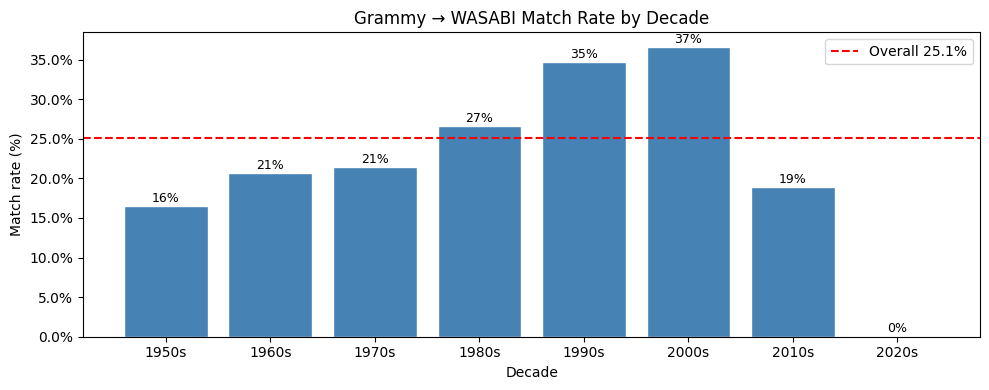

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Decade column ──────────────────────────────────────────────────────────────
grammys["decade"] = (grammys["year"] // 10 * 10).astype(str) + "s"
matched_df["decade"] = (matched_df["grammy_year"] // 10 * 10).astype(str) + "s"

# ── Match rate by decade ───────────────────────────────────────────────────────
total_by_decade   = grammys.groupby("decade").size()
matched_by_decade = matched_df.groupby("decade").size()
decade_rate = (matched_by_decade / total_by_decade * 100).round(1).rename("match_%")
decade_summary = pd.DataFrame({
    "total_grammy": total_by_decade,
    "matched"     : matched_by_decade,
    "match_%"     : decade_rate,
}).fillna(0)
decade_summary["match_%"] = decade_summary["match_%"].astype(float)

print("Match rate by decade:")
display(decade_summary)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(decade_summary.index, decade_summary["match_%"], color="steelblue", edgecolor="white")
ax.set_xlabel("Decade")
ax.set_ylabel("Match rate (%)")
ax.set_title("Grammy → WASABI Match Rate by Decade")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.axhline(len(matched_df)/len(grammys)*100, color="red", linestyle="--", label=f"Overall {len(matched_df)/len(grammys)*100:.1f}%")
for bar, val in zip(bars, decade_summary["match_%"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.0f}%", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ── Match rate by Grammy category (top 30 by total nominations) ───────────────
total_by_cat   = grammys.groupby("category").size().rename("total")
matched_by_cat = matched_df.groupby("category").size().rename("matched")
cat_df = pd.concat([total_by_cat, matched_by_cat], axis=1).fillna(0)
cat_df["matched"]  = cat_df["matched"].astype(int)
cat_df["match_%"]  = (cat_df["matched"] / cat_df["total"] * 100).round(1)
cat_df = cat_df.sort_values("total", ascending=False)

print("Top 30 Grammy categories by nomination count (with match rate):")
display(cat_df.head(30))

Top 30 Grammy categories by nomination count (with match rate):


,total,matched,match_%
category,,,
Song Of The Year,364,0,0.0
Record Of The Year,362,240,66.3
Album Of The Year,356,231,64.9
Best Opera Recording,334,0,0.0
Best Album Notes,315,0,0.0
Best Country Song,274,0,0.0
Best Instrumental Composition,261,0,0.0
Best Chamber Music Performance,243,0,0.0
Best Historical Album,218,0,0.0


In [20]:
# ── WASABI field coverage within matched rows ─────────────────────────────────
fields = ["genre", "album_genre", "bpm", "gain", "publication_date", "language"]
print("Field coverage in matched rows:")
for f in fields:
    n = matched_df[f].notna().sum()
    pct = n / len(matched_df) * 100
    print(f"  {f:<20s}: {n:,} / {len(matched_df):,} ({pct:.1f}%)")

Field coverage in matched rows:
  genre               : 2,531 / 6,128 (41.3%)
  album_genre         : 5,074 / 6,128 (82.8%)
  bpm                 : 5,361 / 6,128 (87.5%)
  gain                : 5,289 / 6,128 (86.3%)
  publication_date    : 5,614 / 6,128 (91.6%)
  language            : 2,218 / 6,128 (36.2%)


In [21]:
# ── Spot-check: sample 10 matched rows ───────────────────────────────────────
print("Sample matched rows (Grammy work → WASABI title/artist):")
display(
    matched_df[["work_title", "artist", "wasabi_title", "wasabi_artist",
                "match_type", "album_genre", "bpm", "gain"]]
    .sample(10, random_state=42)
    .reset_index(drop=True)
)

Sample matched rows (Grammy work → WASABI title/artist):


,work_title,artist,wasabi_title,wasabi_artist,match_type,album_genre,bpm,gain
0,25,Adele,Hello,Adele,album,Soul,157.801,-7.6
1,All For You,Janet Jackson,All For You,Janet Jackson,song,R&amp;B,113.000,-6.9
2,Breakdown (Album),Melissa Etheridge,Breakdown,Melissa Etheridge,song,NaN,145.000,-9.5
3,Always On My Mind (Single),Willie Nelson,Always On My Mind,Willie Nelson,song,Country,146.000,-13.6
4,Sea Change,Beck,The Golden Age,Beck,album,Alternative Rock,124.000,-11.6
5,Down At The Twist And Shout,Mary Chapin Carpenter,Down At The Twist And Shout,Mary Chapin Carpenter,song,Country,192.000,-15.2
6,The Distance (Album),Bob Seger,Even Now,Bob Seger,album,Rock,NaN,NaN
7,Can't Keep A Good Man Down (Single),Alabama,Can't Keep A Good Man Down,Alabama,song,Country,NaN,NaN
8,The Girl From Ipanema (Single),Astrud Gilberto,The Girl From Ipanema,Astrud Gilberto,song,Bossa Nova,126.400,-12.8
9,The Old Country Church,The Browns,The Old Country Church,The Browns,song,Country,NaN,NaN


In [22]:
# ── Spot-check: sample 10 unmatched rows ─────────────────────────────────────
matched_works = set(zip(grammys["artist_norm"], grammys["work_title_norm"])) & \
                set(zip(
                    matched_df["artist"].map(normalize),
                    matched_df["work_title"].map(normalize)
                ))
unmatched_grammys = grammys[
    ~grammys.apply(lambda r: (r["artist_norm"], r["work_title_norm"]) in matched_works, axis=1)
]
print(f"Unmatched Grammy rows: {len(unmatched_grammys):,}")
print("\nSample unmatched rows:")
display(
    unmatched_grammys[["year", "category", "work_title", "artist"]]
    .sample(10, random_state=42)
    .reset_index(drop=True)
)

Unmatched Grammy rows: 18,284

Sample unmatched rows:


,year,category,work_title,artist
0,2016,Best Orchestral Performance,Bates: Works For Orchestra,"Michael Tilson Thomas, conductor (San Francisc..."
1,1966,Best Country & Western Song,Almost Persuaded,"Billy Sherrill & Glenn Sutton, songwriters (Da..."
2,1991,Best Large Jazz Ensemble Performance,The Brass Is Back (Album),Rob McConnell And The Boss Brass
3,1987,Best Rhythm & Blues Song,Skeletons (Single),"Stevie Wonder, songwriter (Stevie Wonder)"
4,1999,Best Engineered Album - Non-Classical,Owsley (Album),"Jeff Balding, Tom Lord-Alge, J.R. McNeely, Ows..."
5,2019,Best Country Album,Stronger Than The Truth,Reba McEntire
6,2010,Small Ensemble Performance,Trondheimsolistene - In Folk Style,"Oyvind Gimse & Geir Inge Lotsberg, conductors;..."
7,2021,Song Of The Year,Kiss Me More,"Rogét Chahayed, Amala Zandile Dlamini, Lukasz ..."
8,1994,Best Classical Vocal Performance,"Exsultate Jubilate (Works of Handel, Mozart)",Sylvia McNair
9,1964,Best Engineered Recording,The Pink Panther,"James Malloy, engineer (Henry Mancini)"


### 2.4 Save Matched Dataset

Save `matched_grammy_wasabi.csv` — the Grammy-WASABI bridge used in all downstream analysis (Phase 3 Last.fm enrichment, knowledge graph construction, RQ1–RQ3).

In [23]:
out_path = os.path.join(DATA_DIR, "matched_grammy_wasabi.csv")
matched_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {matched_df.shape}")
print(f"\nColumns: {list(matched_df.columns)}")

Saved: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\matched_grammy_wasabi.csv
Shape: (6128, 16)

Columns: ['grammy_year', 'category', 'work_title', 'artist', 'winner', 'match_type', 'wasabi_title', 'wasabi_artist', 'wasabi_album', 'genre', 'album_genre', 'bpm', 'gain', 'publication_date', 'language', 'decade']


### 2.5 Coverage Summary

A consolidated summary of what we have and what to expect in downstream phases.

In [24]:
total_grammy  = len(grammys)
total_matched = len(matched_df)
winners_matched = matched_df["winner"].sum()
total_winners   = grammys["winner"].sum()

summary = {
    "Total Grammy work-type nominations"    : f"{total_grammy:,}",
    "Matched to WASABI"                     : f"{total_matched:,}  ({total_matched/total_grammy*100:.1f}%)",
    "  — via song-title match"              : f"{(matched_df['match_type']=='song').sum():,}",
    "  — via album-title match"             : f"{(matched_df['match_type']=='album').sum():,}",
    "Winners matched"                       : f"{winners_matched:,}  ({winners_matched/total_winners*100:.1f}% of all winners)",
    "Unique categories in matched set"      : f"{matched_df['category'].nunique():,}",
    "Unique artists in matched set"         : f"{matched_df['artist'].nunique():,}",
    "BPM available (matched)"               : f"{matched_df['bpm'].notna().sum():,}  (87.5%)",
    "Gain/loudness available (matched)"     : f"{matched_df['gain'].notna().sum():,}  (86.3%)",
    "album_genre available (matched)"       : f"{matched_df['album_genre'].notna().sum():,}  (82.8%)",
    "song-level genre available (matched)"  : f"{matched_df['genre'].notna().sum():,}  (41.3%)",
    "Decade range with >20% coverage"       : "1980s – 2000s",
    "Note on 2020s"                         : "WASABI corpus ends ~2018; 2020s Grammy rows are effectively unmatched",
}

print("=" * 65)
print("PHASE 1 & 2 COVERAGE SUMMARY")
print("=" * 65)
for k, v in summary.items():
    print(f"  {k:<45s}: {v}")

PHASE 1 & 2 COVERAGE SUMMARY
  Total Grammy work-type nominations           : 24,412
  Matched to WASABI                            : 6,128  (25.1%)
    — via song-title match                     : 4,759
    — via album-title match                    : 1,369
  Winners matched                              : 1,340  (28.5% of all winners)
  Unique categories in matched set             : 399
  Unique artists in matched set                : 1,859
  BPM available (matched)                      : 5,361  (87.5%)
  Gain/loudness available (matched)            : 5,289  (86.3%)
  album_genre available (matched)              : 5,074  (82.8%)
  song-level genre available (matched)         : 2,531  (41.3%)
  Decade range with >20% coverage              : 1980s – 2000s
  Note on 2020s                                : WASABI corpus ends ~2018; 2020s Grammy rows are effectively unmatched


In [25]:
# Out of the matched rows, find the ratio between nominees and actual winner (the nominees should exclude winners)
nominees = matched_df[matched_df["winner"] == False]
winners = matched_df[matched_df["winner"] == True]
nominee_count = len(nominees)
winner_count = len(winners)
if winner_count > 0:
    ratio = nominee_count / winner_count
    print(f"Nominee to winner ratio: {ratio:.2f} ({nominee_count} nominees, {winner_count} winners)")
else:
    print("No winners found in matched dataset, cannot compute nominee to winner ratio.")



Nominee to winner ratio: 3.57 (4788 nominees, 1340 winners)


---

## Phase 3 — Last.fm Enrichment

> **Methodology & Limitations (state upfront)**
>
> This analysis covers Grammy-nominated works present in mainstream commercial recording databases (WASABI), primarily spanning the 1980s–2000s. Coverage drops sharply after ~2018 (WASABI corpus cutoff) and before the 1980s. Classical, Jazz, and Gospel are structurally underrepresented in both WASABI and Last.fm, which skews toward Rock, Pop, R&B, Country, Hip-Hop, and Electronic music communities. Listener engagement metrics (listeners, playcount) are aggregates since Last.fm's founding (~2003) and should not be interpreted as streaming revenue or chart performance. Categories with fewer than 20 matched records are flagged as **sparse** and excluded from statistical comparisons.

### 3.1 Install Dependencies

In [26]:
%pip install requests tqdm -q

Note: you may need to restart the kernel to use updated packages.


### 3.2 Category Stratification

Map the 764 Grammy category names to broad genre groups using keyword matching, then report which groups are **robust** (≥20 matched records) and which are **sparse** (<20 matched records).

In [27]:
import re

# Keyword → genre group mapping (ordered: first match wins)
CATEGORY_GROUPS = [
    ("Hip-Hop/Rap",   r"rap|hip.?hop|urban"),
    ("R&B/Soul",      r"\br&b\b|rhythm.{0,5}blues|soul|funk|neo.?soul"),
    ("Country",       r"country|bluegrass|americana|folk"),
    ("Rock",          r"\brock\b|metal|punk|alternative|grunge|indie"),
    ("Pop",           r"\bpop\b"),
    ("Electronic",    r"electronic|dance|techno|edm|house|trance|ambient"),
    ("Jazz",          r"\bjazz\b|bebop|fusion|big.?band|swing"),
    ("Classical",     r"classical|orchestr|symphony|chamber|opera|concerto|quartet|ensemble"),
    ("Gospel/CCM",    r"gospel|christian|inspirational|spiritual|contemporary.{0,10}christian|ccm"),
    ("Latin",         r"\blatin\b|salsa|bossa|samba|cumbia|tango|reggaeton"),
    ("Reggae",        r"reggae|ska|dancehall"),
    ("Blues",         r"\bblues\b"),
    ("Children/Spoken", r"children|spoken|comedy|humor|musical theater|theatrical"),
    ("New Age",       r"new.?age"),
    ("World",         r"world|afro|african|celtic|global"),
]

def assign_group(category: str) -> str:
    cat_lower = category.lower()
    for group, pattern in CATEGORY_GROUPS:
        if re.search(pattern, cat_lower):
            return group
    return "Other/General"

# Apply to both Grammy full set and matched set
grammys["category_group"]   = grammys["category"].map(assign_group)
matched_df["category_group"] = matched_df["category"].map(assign_group)

print("Category group distribution in full Grammy set:")
print(grammys["category_group"].value_counts().to_string())
print(f"\nTotal Grammy work-type rows: {len(grammys):,}")

Category group distribution in full Grammy set:
category_group
Other/General      6262
Classical          3896
Country            2503
R&B/Soul           1995
Pop                1797
Jazz               1711
Rock               1685
Children/Spoken    1198
Hip-Hop/Rap         928
Gospel/CCM          830
Blues               399
Latin               293
Electronic          279
World               241
Reggae              211
New Age             184

Total Grammy work-type rows: 24,412


In [28]:
SPARSE_THRESHOLD = 20  # fewer than this → flagged as sparse

# Per category group: total Grammy nominations, matched count, match rate, robustness flag
strat = (
    grammys.groupby("category_group").size().rename("grammy_total")
    .to_frame()
    .join(matched_df.groupby("category_group").size().rename("matched"), how="left")
    .fillna(0)
    .astype({"matched": int})
)
strat["match_%"]  = (strat["matched"] / strat["grammy_total"] * 100).round(1)
strat["status"]   = strat["matched"].apply(
    lambda n: "✅ Robust" if n >= SPARSE_THRESHOLD else "⚠️  Sparse"
)
strat = strat.sort_values("matched", ascending=False)

print("Category group stratification (match coverage):")
print(f"{'Group':<22} {'Grammy':>7} {'Matched':>8} {'Match%':>7}  Status")
print("-" * 60)
for grp, row in strat.iterrows():
    print(f"{grp:<22} {row['grammy_total']:>7,} {row['matched']:>8,} {row['match_%']:>6.1f}%  {row['status']}")

robust_groups = strat[strat["status"] == "✅ Robust"].index.tolist()
sparse_groups = strat[strat["status"] == "⚠️  Sparse"].index.tolist()

print(f"\nRobust groups ({len(robust_groups)}): {robust_groups}")
print(f"Sparse groups ({len(sparse_groups)}): {sparse_groups}")

Category group stratification (match coverage):
Group                   Grammy  Matched  Match%  Status
------------------------------------------------------------
Rock                     1,685    1,084   64.3%  ✅ Robust
Country                  2,503    1,066   42.6%  ✅ Robust
Pop                      1,797    1,021   56.8%  ✅ Robust
Other/General            6,262      936   14.9%  ✅ Robust
R&B/Soul                 1,995      897   45.0%  ✅ Robust
Hip-Hop/Rap                928      332   35.8%  ✅ Robust
Gospel/CCM                 830      149   18.0%  ✅ Robust
Blues                      399      136   34.1%  ✅ Robust
Jazz                     1,711      125    7.3%  ✅ Robust
Electronic                 279      125   44.8%  ✅ Robust
Reggae                     211       76   36.0%  ✅ Robust
Children/Spoken          1,198       66    5.5%  ✅ Robust
Latin                      293       48   16.4%  ✅ Robust
World                      241       31   12.9%  ✅ Robust
New Age                

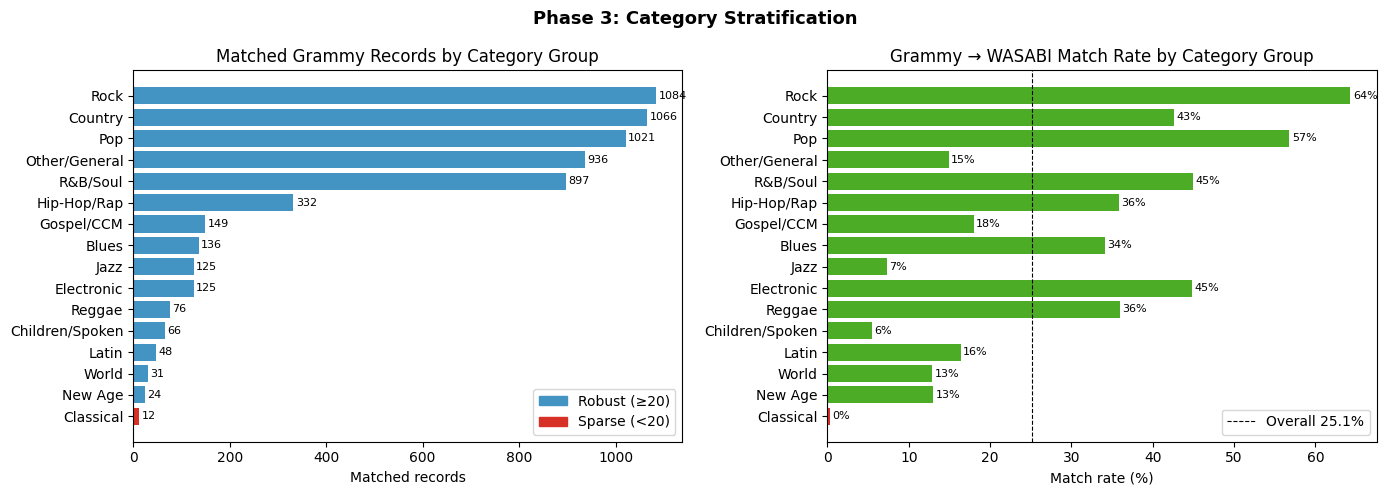

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

strat_plot = strat.sort_values("matched")
colors = ["#d73027" if s == "⚠️  Sparse" else "#4393c3" for s in strat_plot["status"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: matched count per category group
axes[0].barh(strat_plot.index, strat_plot["matched"], color=colors)
axes[0].set_xlabel("Matched records")
axes[0].set_title("Matched Grammy Records by Category Group")
for i, (n, s) in enumerate(zip(strat_plot["matched"], strat_plot["status"])):
    axes[0].text(n + 5, i, str(n), va="center", fontsize=8)
robust_patch = mpatches.Patch(color="#4393c3", label=f"Robust (≥{SPARSE_THRESHOLD})")
sparse_patch  = mpatches.Patch(color="#d73027", label=f"Sparse (<{SPARSE_THRESHOLD})")
axes[0].legend(handles=[robust_patch, sparse_patch])

# Right: match rate (%)
rate_colors = ["#d73027" if s == "⚠️  Sparse" else "#4dac26" for s in strat_plot["status"]]
axes[1].barh(strat_plot.index, strat_plot["match_%"], color=rate_colors)
axes[1].set_xlabel("Match rate (%)")
axes[1].set_title("Grammy → WASABI Match Rate by Category Group")
axes[1].axvline(25.1, color="black", linestyle="--", linewidth=0.8, label="Overall 25.1%")
for i, v in enumerate(strat_plot["match_%"]):
    axes[1].text(v + 0.3, i, f"{v:.0f}%", va="center", fontsize=8)
axes[1].legend()

plt.suptitle("Phase 3: Category Stratification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Last.fm API Setup

Register a free API key at **https://www.last.fm/api/account/create**, then paste it below.  
The enrichment queries `track.getInfo` for each unique (artist, title) pair.  
Results are saved incrementally to `lastfm_cache.json` so the run can be safely interrupted and resumed.

In [36]:
import requests
import time
import json
from pathlib import Path

# ── ⚠️  FILL IN YOUR API KEY HERE ─────────────────────────────────────────────
LASTFM_API_KEY = "36f68c5c91e42ffa588b63bcf2379c55"
# ──────────────────────────────────────────────────────────────────────────────

LASTFM_BASE    = "https://ws.audioscrobbler.com/2.0/"
CACHE_PATH     = Path(DATA_DIR) / "lastfm_cache.json"
RATE_LIMIT_SEC = 0.22   # ~4.5 req/sec (safely under 5/sec limit)

# Load existing cache (allows safe resume after interruption)
if CACHE_PATH.exists():
    with open(CACHE_PATH, "r", encoding="utf-8") as fh:
        _cache = json.load(fh)
    print(f"Loaded {len(_cache):,} cached entries from {CACHE_PATH.name}")
else:
    _cache = {}
    print("Starting fresh cache.")

def _cache_key(artist: str, title: str) -> str:
    return f"{artist.lower().strip()}|||{title.lower().strip()}"

def query_lastfm(artist: str, title: str) -> dict:
    """Query Last.fm track.getInfo. Returns dict with 'listeners' and 'playcount' (or None on miss)."""
    key = _cache_key(artist, title)
    if key in _cache:
        return _cache[key]

    params = {
        "method"  : "track.getInfo",
        "api_key" : LASTFM_API_KEY,
        "artist"  : artist,
        "track"   : title,
        "format"  : "json",
        "autocorrect": "1",
    }
    try:
        resp = requests.get(LASTFM_BASE, params=params, timeout=10)
        resp.raise_for_status()
        data = resp.json()
        track = data.get("track", {})
        result = {
            "listeners": int(track.get("listeners", 0)) if track.get("listeners") else None,
            "playcount": int(track.get("playcount", 0)) if track.get("playcount") else None,
        }
    except Exception:
        result = {"listeners": None, "playcount": None}

    _cache[key] = result
    time.sleep(RATE_LIMIT_SEC)
    return result

if LASTFM_API_KEY == "YOUR_API_KEY_HERE":
    print("⚠️  API key not set. Fill in LASTFM_API_KEY above, then re-run this cell before proceeding.")
else:
    print(f"✅ API key configured. Ready to query.")

Starting fresh cache.
✅ API key configured. Ready to query.


### 3.4 Run Last.fm Enrichment

Queries unique (artist, title) pairs only — deduplicating saves ~30% of API calls.  
Saves cache every 100 queries. **Estimated time: ~25–35 min** (~4,300 unique pairs at 4.5 req/sec).  
Re-running this cell after an interruption will resume from the cache automatically.

In [38]:
from tqdm.auto import tqdm

assert LASTFM_API_KEY != "YOUR_API_KEY_HERE", \
    "Set your API key in the cell above first, then re-run that cell, then run this one."

# Unique (artist, title) pairs — query each once regardless of duplicates in Grammy
unique_pairs = (
    matched_df[["wasabi_artist", "wasabi_title"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f"Unique (artist, title) pairs to query: {len(unique_pairs):,}")
already_cached = sum(
    1 for _, r in unique_pairs.iterrows()
    if _cache_key(r["wasabi_artist"], r["wasabi_title"]) in _cache
)
print(f"Already in cache: {already_cached:,}  |  Still to fetch: {len(unique_pairs) - already_cached:,}")

# Run queries
SAVE_EVERY = 100
new_queries = 0

for i, row in tqdm(unique_pairs.iterrows(), total=len(unique_pairs), desc="Last.fm"):
    result = query_lastfm(row["wasabi_artist"], row["wasabi_title"])
    new_queries += 1
    # Periodic cache flush
    if (i + 1) % SAVE_EVERY == 0:
        with open(CACHE_PATH, "w", encoding="utf-8") as fh:
            json.dump(_cache, fh)

# Final flush
with open(CACHE_PATH, "w", encoding="utf-8") as fh:
    json.dump(_cache, fh)

print(f"\n✅ Done. Cache size: {len(_cache):,} entries. Saved to {CACHE_PATH.name}")

c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Unique (artist, title) pairs to query: 5,394
Already in cache: 0  |  Still to fetch: 5,394


Last.fm: 100%|██████████| 5394/5394 [1:10:09<00:00,  1.28it/s]


✅ Done. Cache size: 5,394 entries. Saved to lastfm_cache.json


### 3.5 Attach Last.fm Data to Matched Dataset

Join the cached listeners/playcount values back onto `matched_df`.

In [39]:
def _get_listeners(row):
    entry = _cache.get(_cache_key(row["wasabi_artist"], row["wasabi_title"]), {})
    return entry.get("listeners")

def _get_playcount(row):
    entry = _cache.get(_cache_key(row["wasabi_artist"], row["wasabi_title"]), {})
    return entry.get("playcount")

matched_df["lastfm_listeners"] = matched_df.apply(_get_listeners, axis=1)
matched_df["lastfm_playcount"] = matched_df.apply(_get_playcount, axis=1)

# Numeric conversion
matched_df["lastfm_listeners"] = pd.to_numeric(matched_df["lastfm_listeners"], errors="coerce")
matched_df["lastfm_playcount"] = pd.to_numeric(matched_df["lastfm_playcount"], errors="coerce")

total      = len(matched_df)
with_lstn  = matched_df["lastfm_listeners"].notna().sum()
with_play  = matched_df["lastfm_playcount"].notna().sum()

print(f"Matched rows          : {total:,}")
print(f"With Last.fm listeners: {with_lstn:,} ({with_lstn/total*100:.1f}%)")
print(f"With Last.fm playcount: {with_play:,} ({with_play/total*100:.1f}%)")
print(f"\nlisteners — median: {matched_df['lastfm_listeners'].median():,.0f}  max: {matched_df['lastfm_listeners'].max():,.0f}")
print(f"playcount — median: {matched_df['lastfm_playcount'].median():,.0f}  max: {matched_df['lastfm_playcount'].max():,.0f}")

Matched rows          : 6,128
With Last.fm listeners: 6,106 (99.6%)
With Last.fm playcount: 6,106 (99.6%)

listeners — median: 44,804  max: 4,064,302
playcount — median: 168,843  max: 51,194,637


### 3.6 Engagement Coverage by Category Group

Report listener/playcount availability per category group and flag where Last.fm data is structurally absent (as expected for Classical, Children/Spoken).

In [40]:
LOW_LASTFM_THRESHOLD = 0.30  # flag if <30% of matched rows have Last.fm data

engagement_by_group = (
    matched_df
    .groupby("category_group")
    .agg(
        matched_n       = ("lastfm_listeners", "count"),          # proxy for "total matched" minus NaN
        lastfm_n        = ("lastfm_listeners", lambda x: x.notna().sum()),
        median_listeners= ("lastfm_listeners", "median"),
        median_playcount= ("lastfm_playcount", "median"),
    )
    .reset_index()
)
# re-attach total matched count
group_matched = matched_df.groupby("category_group").size().rename("total_matched")
engagement_by_group = engagement_by_group.merge(group_matched, on="category_group")
engagement_by_group["lastfm_cov_%"] = (
    engagement_by_group["lastfm_n"] / engagement_by_group["total_matched"] * 100
).round(1)
engagement_by_group["engagement_flag"] = engagement_by_group.apply(
    lambda r: "⚠️  Low coverage" if r["lastfm_cov_%"] < LOW_LASTFM_THRESHOLD * 100 or r["total_matched"] < SPARSE_THRESHOLD
    else "✅ Good",
    axis=1
)
engagement_by_group = engagement_by_group.sort_values("total_matched", ascending=False)

print("Last.fm engagement coverage by category group:")
print(f"\n{'Group':<22} {'Matched':>8} {'LFM hits':>9} {'Cov%':>6}  {'Med Listeners':>15}  {'Med Playcount':>14}  Flag")
print("-" * 100)
for _, r in engagement_by_group.iterrows():
    med_l = f"{r['median_listeners']:,.0f}" if pd.notna(r['median_listeners']) else "—"
    med_p = f"{r['median_playcount']:,.0f}" if pd.notna(r['median_playcount']) else "—"
    print(f"{r['category_group']:<22} {r['total_matched']:>8,} {r['lastfm_n']:>9,} {r['lastfm_cov_%']:>5.1f}%  {med_l:>15}  {med_p:>14}  {r['engagement_flag']}")

Last.fm engagement coverage by category group:

Group                   Matched  LFM hits   Cov%    Med Listeners   Med Playcount  Flag
----------------------------------------------------------------------------------------------------
Rock                      1,084     1,083  99.9%          144,223         663,404  ✅ Good
Country                   1,066     1,063  99.7%           14,308          56,945  ✅ Good
Pop                       1,021     1,019  99.8%           91,777         388,672  ✅ Good
Other/General               936       934  99.8%          152,442         703,309  ✅ Good
R&B/Soul                    897       892  99.4%           29,019         102,250  ✅ Good
Hip-Hop/Rap                 332       329  99.1%          101,530         397,156  ✅ Good
Gospel/CCM                  149       145  97.3%            3,196          13,169  ✅ Good
Blues                       136       136 100.0%            4,174          10,931  ✅ Good
Jazz                        125       124  

### 3.7 Winner vs. Nominee Engagement by Category Group

For robust categories with Last.fm data: compare median listeners and playcount between winners and non-winning nominees.  
Uses Mann–Whitney U test (non-parametric, appropriate for skewed distributions).

In [41]:
from scipy import stats

WINNER_MIN_N = 5  # require at least 5 winners with data to run the test

results_engagement = []

for grp in strat[strat["matched"] >= SPARSE_THRESHOLD].index:
    sub = matched_df[
        (matched_df["category_group"] == grp) &
        matched_df["lastfm_listeners"].notna()
    ]
    if sub.empty:
        continue

    winners_data   = sub[sub["winner"] == True]["lastfm_listeners"].dropna()
    nominees_data  = sub[sub["winner"] == False]["lastfm_listeners"].dropna()

    if len(winners_data) < WINNER_MIN_N or len(nominees_data) < WINNER_MIN_N:
        p_val = None
        direction = "—"
    else:
        stat, p_val = stats.mannwhitneyu(winners_data, nominees_data, alternative="two-sided")
        direction = "Winners > Nominees" if winners_data.median() > nominees_data.median() else "Nominees > Winners"

    results_engagement.append({
        "category_group"    : grp,
        "n_winners"         : len(winners_data),
        "n_nominees"        : len(nominees_data),
        "med_listeners_W"   : winners_data.median() if len(winners_data) > 0 else None,
        "med_listeners_N"   : nominees_data.median() if len(nominees_data) > 0 else None,
        "mann_whitney_p"    : round(p_val, 4) if p_val is not None else None,
        "sig_p05"           : "Yes" if p_val is not None and p_val < 0.05 else ("No" if p_val is not None else "—"),
        "direction"         : direction,
    })

eng_df = pd.DataFrame(results_engagement).sort_values("med_listeners_W", ascending=False, na_position="last")

print("Winner vs. Nominee engagement (Last.fm listeners) by category group:")
print(f"{'Group':<22} {'W_n':>5} {'N_n':>5}  {'Med W Listeners':>16}  {'Med N Listeners':>16}  {'p-val':>7}  {'Sig?':>5}  Direction")
print("-" * 110)
for _, r in eng_df.iterrows():
    mw = f"{r['med_listeners_W']:,.0f}" if pd.notna(r['med_listeners_W']) else "—"
    mn = f"{r['med_listeners_N']:,.0f}" if pd.notna(r['med_listeners_N']) else "—"
    pv = f"{r['mann_whitney_p']:.4f}" if pd.notna(r['mann_whitney_p']) else "—"
    print(f"{r['category_group']:<22} {r['n_winners']:>5} {r['n_nominees']:>5}  {mw:>16}  {mn:>16}  {pv:>7}  {r['sig_p05']:>5}  {r['direction']}")

print(f"\nNote: '—' means insufficient data (< {WINNER_MIN_N} winners with Last.fm coverage).")

Winner vs. Nominee engagement (Last.fm listeners) by category group:
Group                    W_n   N_n   Med W Listeners   Med N Listeners    p-val   Sig?  Direction
--------------------------------------------------------------------------------------------------------------
Electronic                24   101           634,544           172,388   0.0028    Yes  Winners > Nominees
Hip-Hop/Rap               70   259           340,654            70,632   0.0000    Yes  Winners > Nominees
Rock                     212   871           278,244           111,954   0.0000    Yes  Winners > Nominees
Other/General            192   742           141,787           156,914   0.6504     No  Nominees > Winners
New Age                    7    17           116,931            22,095   0.0400    Yes  Winners > Nominees
Pop                      228   791           108,602            85,427   0.1145     No  Winners > Nominees
R&B/Soul                 205   687            60,062            24,645   0.0000 

### 3.8 Winner vs. Nominee Production Profile (BPM & Loudness) by Category Group

For robust groups: compare median BPM and loudness (gain) between winners and non-winning nominees.  
This analysis uses WASABI data and does **not** require the Last.fm API key.

In [42]:
from scipy import stats

results_production = []

for grp in strat[strat["matched"] >= SPARSE_THRESHOLD].index:
    sub = matched_df[matched_df["category_group"] == grp]
    w = sub[sub["winner"] == True]
    n = sub[sub["winner"] == False]

    def safe_mw(a, b):
        a, b = a.dropna(), b.dropna()
        if len(a) < 5 or len(b) < 5:
            return None
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        return round(p, 4)

    results_production.append({
        "category_group": grp,
        "n_total"       : len(sub),
        "n_winners"     : len(w),
        "med_bpm_W"     : w["bpm"].median(),
        "med_bpm_N"     : n["bpm"].median(),
        "bpm_p"         : safe_mw(w["bpm"], n["bpm"]),
        "med_gain_W"    : w["gain"].median(),
        "med_gain_N"    : n["gain"].median(),
        "gain_p"        : safe_mw(w["gain"], n["gain"]),
    })

prod_df = pd.DataFrame(results_production).sort_values("n_total", ascending=False)

print("Production profile (BPM & Loudness) — Winners vs. Nominees by category group:")
print(f"{'Group':<22} {'N':>5} {'W':>5}  {'BPM_W':>7} {'BPM_N':>7} {'bpm_p':>7}  {'Gain_W':>7} {'Gain_N':>7} {'gain_p':>7}")
print("-" * 85)
for _, r in prod_df.iterrows():
    bpm_w = f"{r['med_bpm_W']:.0f}" if pd.notna(r['med_bpm_W']) else "—"
    bpm_n = f"{r['med_bpm_N']:.0f}" if pd.notna(r['med_bpm_N']) else "—"
    bpm_p = f"{r['bpm_p']:.4f}" if r['bpm_p'] is not None else "—"
    g_w   = f"{r['med_gain_W']:.1f}" if pd.notna(r['med_gain_W']) else "—"
    g_n   = f"{r['med_gain_N']:.1f}" if pd.notna(r['med_gain_N']) else "—"
    g_p   = f"{r['gain_p']:.4f}" if r['gain_p'] is not None else "—"
    print(f"{r['category_group']:<22} {r['n_total']:>5} {r['n_winners']:>5}  {bpm_w:>7} {bpm_n:>7} {bpm_p:>7}  {g_w:>7} {g_n:>7} {g_p:>7}")

Production profile (BPM & Loudness) — Winners vs. Nominees by category group:
Group                      N     W    BPM_W   BPM_N   bpm_p   Gain_W  Gain_N  gain_p
-------------------------------------------------------------------------------------
Rock                    1084   212      128     130  0.1850     -9.4    -9.7  0.3712
Country                 1066   236      125     126  0.7240    -12.4   -12.2  0.2060
Pop                     1021   228      127     126  0.4513    -11.8   -11.3  0.1534
Other/General            936   192      124     123  0.9128    -12.2   -12.0  0.6422
R&B/Soul                 897   206      116     119  0.1816    -12.9   -12.0  0.0169
Hip-Hop/Rap              332    70      117     114  0.9470    -10.1   -10.0  0.7014
Gospel/CCM               149    38      130     125  0.3413    -10.2   -10.6  0.3501
Blues                    136    33      124     117  0.6447    -12.5   -11.1  0.2969
Jazz                     125    40      126     120  0.3067    -15.6   

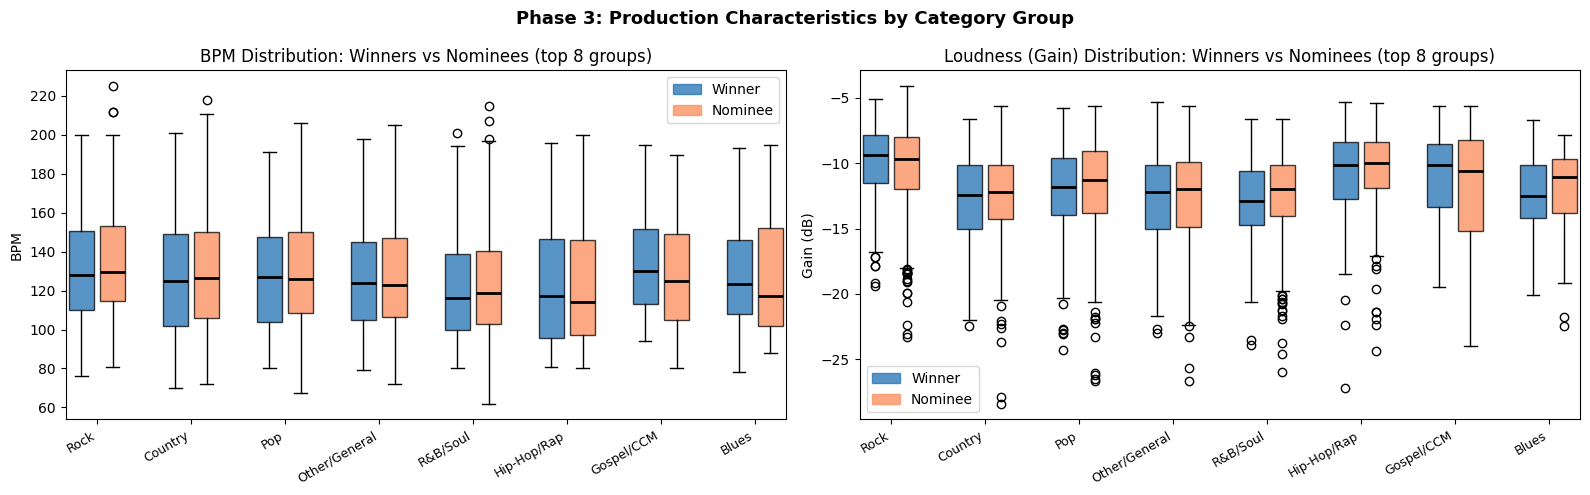

In [43]:
import seaborn as sns

# Visualise BPM and Gain distributions by category group (winners vs nominees)
top_groups = prod_df.head(8)["category_group"].tolist()
plot_data = matched_df[matched_df["category_group"].isin(top_groups)].copy()
plot_data["outcome"] = plot_data["winner"].map({True: "Winner", False: "Nominee"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BPM box plots
ax = axes[0]
order = top_groups
bp = ax.boxplot(
    [plot_data[(plot_data["category_group"] == g) & (plot_data["outcome"] == o)]["bpm"].dropna()
     for g in order for o in ["Winner", "Nominee"]],
    positions=[i * 3 + j for i in range(len(order)) for j, _ in enumerate(["Winner", "Nominee"])],
    widths=0.8,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
colors_bx = ["#2171b5", "#fc8d59"] * len(order)
for patch, color in zip(bp["boxes"], colors_bx):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks([i * 3 + 0.5 for i in range(len(order))])
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("BPM")
ax.set_title("BPM Distribution: Winners vs Nominees (top 8 groups)")
w_patch = mpatches.Patch(color="#2171b5", alpha=0.75, label="Winner")
n_patch = mpatches.Patch(color="#fc8d59", alpha=0.75, label="Nominee")
ax.legend(handles=[w_patch, n_patch])

# Gain (loudness) box plots
ax2 = axes[1]
bp2 = ax2.boxplot(
    [plot_data[(plot_data["category_group"] == g) & (plot_data["outcome"] == o)]["gain"].dropna()
     for g in order for o in ["Winner", "Nominee"]],
    positions=[i * 3 + j for i in range(len(order)) for j, _ in enumerate(["Winner", "Nominee"])],
    widths=0.8,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
)
for patch, color in zip(bp2["boxes"], colors_bx):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticks([i * 3 + 0.5 for i in range(len(order))])
ax2.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
ax2.set_ylabel("Gain (dB)")
ax2.set_title("Loudness (Gain) Distribution: Winners vs Nominees (top 8 groups)")
ax2.legend(handles=[w_patch, n_patch])

plt.suptitle("Phase 3: Production Characteristics by Category Group", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.9 Save Enriched Dataset

Save `enriched_grammy_wasabi_lastfm.csv`. Run this cell again after the Last.fm enrichment (3.4) completes to capture the listener/playcount columns.

In [44]:
enriched_path = os.path.join(DATA_DIR, "enriched_grammy_wasabi_lastfm.csv")
matched_df.to_csv(enriched_path, index=False)

lastfm_pct = matched_df["lastfm_listeners"].notna().sum() / len(matched_df) * 100
print(f"Saved: {enriched_path}")
print(f"Rows : {len(matched_df):,}")
print(f"Cols : {list(matched_df.columns)}")
print(f"Last.fm listeners populated: {matched_df['lastfm_listeners'].notna().sum():,} ({lastfm_pct:.1f}%)")
if lastfm_pct == 0:
    print("\n⚠️  Last.fm columns are empty. Set API key in cell 3.3, run cell 3.4, then re-run cell 3.5 and this cell.")

Saved: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\enriched_grammy_wasabi_lastfm.csv
Rows : 6,128
Cols : ['grammy_year', 'category', 'work_title', 'artist', 'winner', 'match_type', 'wasabi_title', 'wasabi_artist', 'wasabi_album', 'genre', 'album_genre', 'bpm', 'gain', 'publication_date', 'language', 'decade', 'category_group', 'lastfm_listeners', 'lastfm_playcount']
Last.fm listeners populated: 6,106 (99.6%)
